### Plot of heatmap of node communities  
Import packages

In [1]:
import sys
import pickle
sys.path.append('../analysis')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
from collections import deque
from MBN_Res_Constrn import MBN_RC
from ClusterTracking import SCTA

Import MB_communities

In [2]:
with open('../Mouse brain network/MouseBrainLib/mb_communities_dict.pickle', 'rb') as f:
    _x = pickle.load(f)

Import  
1. iteration data
2. node communities data (threshold=0.5)
3. local order data

In [3]:
df_itr=pd.read_pickle('../../data/Raw/FN/itr_data_fn.bz2')
df_nc=pd.read_pickle('../../data/Raw/check_20/nc_fn_20.bz2')
df_lo=pd.read_pickle('../../data/Raw/FN/l200.bz2')
df_toe = pd.read_pickle('../../data/Raw/check_20/toe_fn_20.bz2')

Make node_communities data according to MBcommunity ordered by synchronisation  
Order:  or,ol,ht,v,m,hc,mb,hb  


In [36]:
df_lo.head()

0         1         2         3         4         5         6     \
5 0  0.157077  0.160598  0.164243  0.167994  0.171832  0.175742  0.179711   
  1  0.014478  0.014080  0.013944  0.014074  0.014469  0.015114  0.015994   
  2  0.149793  0.147797  0.145818  0.143863  0.141938  0.140049  0.138203   
  3  0.198785  0.197699  0.196459  0.195061  0.193506  0.191792  0.189918   
  4  0.152710  0.152665  0.152518  0.152271  0.151924  0.151476  0.150929   

         7         8         9     ...      4990      4991      4992  \
5 0  0.183728  0.187782  0.191867  ...  0.657623  0.656920  0.656157   
  1  0.017091  0.018388  0.019871  ...  0.377835  0.377250  0.376560   
  2  0.136404  0.134660  0.132974  ...  0.456650  0.459205  0.461634   
  3  0.187888  0.185701  0.183362  ...  0.431043  0.429522  0.427761   
  4  0.150284  0.149541  0.148703  ...  0.550049  0.551696  0.553135   

         4993      4994      4995      4996      4997      4998      4999  
5 0  0.655335  0.654453  0.653508  0.652500  0.651427  0.650286  0.649074  
  1  0.375769  0.374881  0.373902  0.372839  0.371695  0.370479  0.369196  
  2  0.463936  0.466107  0.468149  0.470062  0.471849  0.473514  0.475060  
  3  0.425767  0.423548  0.421113  0.418471  0.415630  0.412602  0.409398  
  4  0.554368  0.555397  0.556229  0.556871  0.557334  0.557629  0.557769  

[5 rows x 5000 columns]

In [ ]:
m_lo = (df_lo.loc[5].iloc[0:426]).values

In [43]:
a=m_lo.T
m_lo_ar=a[:,new_order]

In [44]:
m_lo_ar.shape

(5000, 426)

In [4]:
df_nc.loc[1].shape

(5000, 426)

In [114]:
desired_keys = [3,6,4,2,0,7,1,5]
_x_rearrange = {key: _x[key] for key in desired_keys}

desired_order = [item for sublist in _x_rearrange.values() for item in sublist]
rearranged_matrix = matrix[:, desired_order]

Within each community sort the nodes in decreasing order of total time spent in the final cluster

In [84]:
#choosing node 23 as it is from orbital area,making sure it enters the main cluster
main_cluster_index = (df_nc.loc[1])[23].value_counts().index[1]
#plt.hist(matrix[4000, :], bins=100, range=(1, 5));

In [85]:
main_cluster_index

3.0

In [36]:
rearranged_matrix.shape

(5000, 426)

In [86]:
_x_rearrange.keys()

dict_keys([3, 6, 4, 2, 0, 7, 1, 5])

In [6]:
len_comm=[len(v) for v in _x_rearrange.values()]
len_comm

[34, 36, 44, 50, 56, 50, 70, 86]

Re-arranging ToE data in MB community order of nodes

In [115]:
toe_matrix=df_toe.values
toe_matrix_rearr = toe_matrix[:,desired_order]

In [120]:
toe_matrix[:,22]

array([4956., 4999., 3408., 4430., 4062., 3427., 4999., 3663., 4347.,
       3672., 4987., 3361., 4346., 3481., 3570., 3656., 4999., 4999.,
       4038., 3413.])

In [122]:
toe_matrix_rearr[0,0]

4956.0

In [123]:
toe_matrix.shape

(20, 426)

In [124]:
rearranged_matrix.shape

(5000, 426)

In [133]:
time_spent=0
for i in range(4956,5000):
    if rearranged_matrix[i,0] == main_cluster_index:
        time_spent+=1
    

In [134]:
time_spent

44

In [132]:
toe_st=toe_matrix_rearr[0,0]
print(toe_st)

4956.0


Therefore, to calculate time spent just count how many times it was in main cluster

In [155]:
rearranged_matrix.shape

(5000, 426)

In [162]:
main_cluster_index

3.0

Calculating time spent by each node of a community in main cluster

In [175]:
time_spent=0
ts=[]
#c for comm. [0 to 7]
com_count=0
c=0
last=len_comm[0]
for i in range(34,34+len_comm[1]):
    
    for j in range(0,5000):
                
        if rearranged_matrix[j][i] == main_cluster_index:
            time_spent+=1
                    
        else:
            pass
        
    ts.append(time_spent)
    



Complete code to calculate time spent for every node in matrix    

In [196]:
time_spent=0
ts=[]
#c for comm. [0 to 7]
com_count=0
c=0
last=len_comm[0]
for l in range(0,8):
    for i in range(c,last):
        
        for j in range(0,5000):
                    
            if rearranged_matrix[j][i] == main_cluster_index:
                time_spent+=1
                        
            else:
                pass
            
        ts.append(time_spent)
        time_spent=0
    
    c=len_comm[com_count]
    com_count+=1
    if com_count<8:
        last=c+len_comm[com_count]
    else:
        break



Sort by time spent for each MB community

In [220]:
time_spent=0
ts=[]
#c for comm. [0 to 7]
com_count=0
c=0
last=len_comm[0]
for l in range(0,8):
    #l for iterating communities
    for i in range(c,last):
        #i for iterating node
        
        for j in range(0,5000):
            #j for iterating timestep
                    
            if rearranged_matrix[j][i] == main_cluster_index:
                time_spent+=1
                        
            else:
                pass
            
        ts.append(time_spent)
        time_spent=0

    
    c=len_comm[com_count]
    com_count+=1
    if com_count<8:
        last=c+len_comm[com_count]
    else:
        break



#### Adding sort by time spent
final

In [247]:
time_spent=0
ts=[]
#c for comm. [0 to 7]
com_count=0
c=0
last=len_comm[0]
dict_sort={}

for l in range(0,8):
    #l for iterating communities
    keys=[]
    values=[]
    for i in range(c,last):
        #i for iterating node
        
        for j in range(0,5000):
            #j for iterating timestep
                    
            if rearranged_matrix[j][i] == main_cluster_index:
                time_spent+=1
                        
            else:
                pass
            
        ts.append(time_spent)
        time_spent=0

    keys=list(range(c,last))
    values=ts[c:last]
    dict_0=dict(zip(keys,values))
    sorted_dict_dum = {k: v for k, v in sorted(dict_0.items(), key=lambda item: item[1],reverse=True)}
    dict_sort = dict_sort | sorted_dict_dum
    c=last
    com_count+=1
    if com_count<8:
        last=last+len_comm[com_count]
    else:
        break



New order with node in a community sorted in descending order

In [252]:
new_order=list(dict_sort.keys())
print(new_order)

[25, 7, 6, 10, 26, 22, 4, 24, 1, 31, 19, 14, 15, 11, 12, 5, 17, 16, 30, 29, 8, 33, 32, 27, 0, 13, 18, 9, 23, 2, 3, 28, 21, 20, 46, 39, 41, 53, 50, 35, 45, 43, 36, 54, 37, 38, 57, 51, 60, 42, 40, 56, 63, 49, 48, 68, 34, 55, 64, 69, 59, 61, 52, 44, 67, 66, 62, 65, 58, 47, 72, 76, 71, 92, 111, 73, 88, 93, 97, 109, 77, 90, 78, 100, 107, 99, 79, 110, 85, 94, 86, 98, 103, 83, 112, 105, 104, 70, 89, 84, 91, 81, 82, 75, 102, 106, 96, 87, 95, 74, 108, 101, 80, 113, 131, 129, 154, 117, 132, 135, 139, 157, 140, 134, 133, 137, 150, 120, 115, 141, 124, 114, 119, 130, 153, 128, 125, 142, 118, 158, 138, 155, 122, 160, 123, 127, 149, 159, 136, 144, 147, 116, 156, 148, 152, 145, 126, 161, 121, 143, 146, 163, 162, 151, 179, 180, 177, 208, 206, 188, 215, 181, 192, 210, 184, 209, 187, 205, 216, 189, 164, 218, 217, 191, 219, 178, 190, 176, 185, 186, 170, 172, 204, 213, 175, 200, 171, 203, 198, 182, 207, 214, 211, 194, 166, 199, 196, 183, 197, 168, 212, 202, 195, 201, 174, 173, 169, 193, 165, 167, 225, 255,

In [253]:
final_matrix = rearranged_matrix[:, new_order]

Plotting global order

In [26]:
dt=0.05
#put  iteration number for which you want to plot
df_smooth=df_itr['5'].rolling(window=800, center=True).mean()

#defining time and timesteps for data
time_steps = list(range(0,df_smooth.shape[0]))   
time=np.multiply(time_steps,dt)

df_smooth

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
39995   NaN
39996   NaN
39997   NaN
39998   NaN
39999   NaN
Name: 5, Length: 40000, dtype: float64

In [27]:
cross = df_smooth[df_smooth>0.3].index[0]

In [34]:
matrix.value_counts()

AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

In [12]:
len_comm

[34, 36, 44, 50, 56, 50, 70, 86]

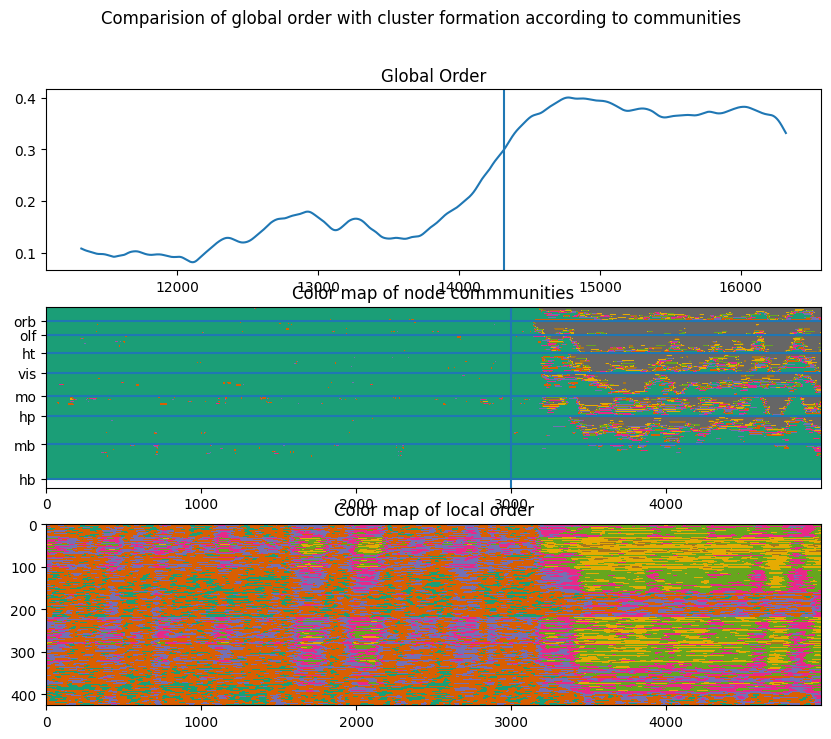

In [55]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8))
label_in=[]
axs[0].plot(time_steps[cross-3000:cross+2000],df_smooth[cross-3000:cross+2000])
axs[0].set_title('Global Order')
axs[0].axvline(cross)
#axs[0].axvline(6780)
#axs[0].axvline(9780+2000)
np.place(final_matrix,final_matrix==0,np.nan)
#np.place(final_matrix,final_matrix!=main_cluster_index,-1)
#np.place(final_matrix,final_matrix==main_cluster_index,1)
axs[1].imshow(final_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    label_in.append(_i)
    axs[1].axhline(_i)
axs[1].axvline(3000)
label=['orb','olf','ht','vis','mo','hp','mb','hb']

axs[1].set_yticks(label_in)
axs[1].set_yticklabels(label)

#fig.colorbar(cax1, ax=axs[1])
#colorbar=plt.colorbar()
axs[1].set_title('Color map of node commmunities')


axs[2].set_title('Color map of local order')
axs[2].imshow(m_lo_ar.T,cmap='Dark2',aspect='auto')
plt.suptitle('Comparision of global order with cluster formation according to communities')
plt.savefig('compa_3_threshold')

#### binarize colormap

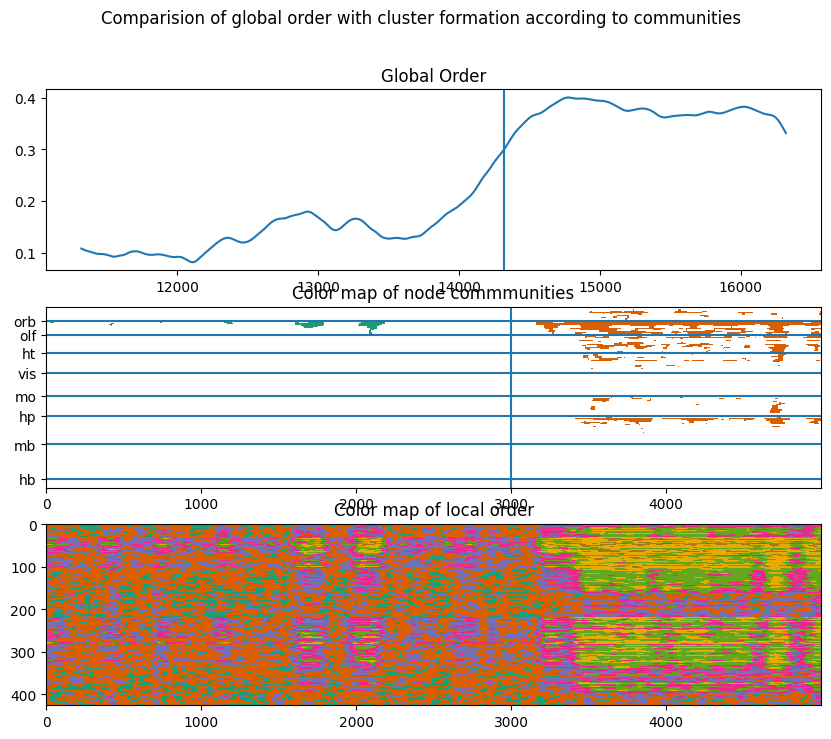

In [47]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8))
label_in=[]
axs[0].plot(time_steps[cross-3000:cross+2000],df_smooth[cross-3000:cross+2000])
axs[0].set_title('Global Order')
axs[0].axvline(cross)
#axs[0].axvline(6780)
#axs[0].axvline(9780+2000)
np.place(final_matrix,final_matrix==0,np.nan)

axs[1].imshow(final_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    label_in.append(_i)
    axs[1].axhline(_i)
axs[1].axvline(3000)
label=['orb','olf','ht','vis','mo','hp','mb','hb']

axs[1].set_yticks(label_in)
axs[1].set_yticklabels(label)

#fig.colorbar(cax1, ax=axs[1])
#colorbar=plt.colorbar()
axs[1].set_title('Color map of node commmunities')
np.place(final_matrix,matrix==0,np.nan)

axs[2].set_title('Color map of local order')
axs[2].imshow(m_lo_ar.T,cmap='Dark2',aspect='auto')
plt.suptitle('Comparision of global order with cluster formation according to communities')
plt.savefig('compa_5_binarize')

In [23]:
final_matrix.shape

(5000, 426)

In [24]:
matrix.shape

(5000, 426)

In [22]:
len_comm

[34, 36, 44, 50, 56, 50, 70, 86]

In [52]:
#Read node community data for a transition
matrix=df_nc.loc[1].values
#Desired order i.e the sequence in which communities enter final cluster  in FN

#choosing node 23 as it is from orbital area,making sure it enters the main cluster
main_cluster_index = (df_nc.loc[1])[23].value_counts().index[1]
#the order in which community enters main cluster (may need to check)
desired_keys = [3,6,4,2,0,7,1,5]
#Arranged _x dictionary data in desired order
_x_rearrange = {key: _x[key] for key in desired_keys}
desired_order = [item for sublist in _x_rearrange.values() for item in sublist]
rearranged_matrix = matrix[:, desired_order]
#counting nodes in each community
len_comm=[len(v) for v in _x_rearrange.values()]
#Calculating time spent and sorting in descending order community wise

time_spent=0
ts=[]
#c for comm. [0 to 7]
com_count=0
c=0
last=len_comm[0]
dict_sort={}

for l in range(0,8):
    #l for iterating communities
    keys=[]
    values=[]
    for i in range(c,last):
        #i for iterating node
        
        for j in range(0,5000):
            #j for iterating timestep
                    
            if rearranged_matrix[j][i] == main_cluster_index:
                time_spent+=1
                        
            else:
                pass
            
        ts.append(time_spent)
        time_spent=0

    keys=list(range(c,last))
    values=ts[c:last]
    dict_0=dict(zip(keys,values))
    sorted_dict_dum = {k: v for k, v in sorted(dict_0.items(), key=lambda item: item[1],reverse=True)}
    dict_sort = dict_sort | sorted_dict_dum
    c=last
    com_count+=1
    if com_count<8:
        last=last+len_comm[com_count]
    else:
        break

#rearranging matrix in the new order
new_order=list(dict_sort.keys())
final_matrix = rearranged_matrix[:, new_order]